<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/SARSA_semi_gradiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SARSA semi-gradiente

*Description*: En este notebook se desarrolla la implementación del método de **SARSA semi-gradiente**, y se emplea sobre el entorno MountainCar de Gymnasium.


    Autores: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín

    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
            
    Date: 2026/02/20


Empezamos instalando e importando las librerías necesarias. También definimos los dispositivos donde se ejecutará el notebook y la semilla que vamos a usar para asegurar reproducibilidad.

In [1]:
! pip install "gymnasium[classic_control]"
! pip install "gymnasium[other]"

In [2]:
! git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL

fatal: destination path 'FernandezMartinezPolo-EML-RL' already exists and is not an empty directory.


In [3]:
%cd FernandezMartinezPolo-EML-RL/Entornos_Complejos

/content/FernandezMartinezPolo-EML-RL/Entornos_Complejos


In [4]:
# Importamos todas las clases y funciones
import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('./src')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import torch
import gc
import os
from IPython.display import Video
from tiling.tiles3 import tiles, IHT
from itertools import product

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', './src']


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


gc.collect()              # Ejecuta el recolector de basura de Python
if torch.cuda.is_available():
    torch.cuda.empty_cache()   # Limpia la caché de la GPU


SEED = 123

# NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)

# Esta semilla se usará para el reseteo del
# entorno de Gymnasium
gym_env_seed = 0

# El nombre del entorno de Gymnasium usado
env_name = "MountainCar-v0"

Usando dispositivo: cpu


## 1. Introducción.

En notebooks pasados se vio cómo se podían resolver problemas tales como Taxi-v3 o Frozen Lake usando métodos tabulares como SARSA o MonteCarlo. Sin embargo, esto solo era posible en entornos discretos con un número reducido de estados. En caso de tener un problema con una combinación demasiado grande de estados, o en un problema con estados continuos, estos métodos dejan de funcionar correctamente debido a varios motivos:

- **Inviabilidad computacional:** haría falta una cantidad enorme de memoria y de tiempo de cómputo para tener en cuenta todos los posibles estados.
- **Falta de generalidad:** dos estados similares no compartirían nada de información, aunque en la práctica se podrían considerar estados aproximadamente iguales.

Un ejemplo de este entorno es MountainCar-v0, donde el agente controla un coche en un entorno bidimensional que debe salir de un valle para poder llegar a la parte más alta de una colina, donde se sitúa la meta. Al llegar a la meta, el problema se considera resuelto.

El estado del agente en este entorno está definido por la posición en el eje X del coche y la velocidad, ambas continuas. Debido a esto, es imposible utilizar un método tabular como los usados anteriormente, por lo que se deberá optar por otro tipo de métodos: los métodos aproximados.

Un ejemplo de método aproximado es SARSA semi-gradiente, un método basado en SARSA que permite resolver problemas con un espacio de estados prohibitivamente grande. En SARSA, para calcular $\hat{Q}(s,a)$ simplemente se debía consultar una tabla, donde había una entrada para cada par $(s,a)$. Ahora, ya que no es posible utilizar esa tabla, se pasará a utilizar una función parametrizada por un vector de parámetros $\mathbf w$:

$$\hat{Q}(s,a,\mathbf{w}) \approx Q^\pi(s,a)$$

Ahora, aprender ya no significa rellenar una tabla, sino encontrar los parámetros del vector $\mathbf w$ que hacen que $\hat{Q}$ sea una buena aproximación de $Q^\pi$. Este enfoque resuelve los dos problemas mencionados anteriormente:

- **Viabilidad computacional:** el vector $\mathbf w$ puede tener cientos o miles de elementos, pero siempre es un número finito.
- **Generalidad:** al actualizar el vector $\mathbf w$ en base a una experiencia en el estado $s$ se está cambiando la función entera, lo que mejora las estimaciones en estados cercanos a $s$.

La aproximación más sencilla de este enfoque es la aproximación lineal, en la que se transforma el par $(s,a)$ en un vector de características $\mathbf x(s,a)$. Para calcular $\hat{Q}(s,a,\mathbf w)$ se tendría que hacer un producto escalar entre el vector de características y el vector de parámetros:

$$\hat{Q}(s,a,\mathbf w) = \mathbf w^\top \mathbf x(s,a)$$

El vector $\mathbf x(s,a)$ es un vector que deberemos definir más adelante, y que depende del problema a resolver, pues debe codificar información relevante del estado $s$ y de la acción $a$.

Una vez definido el vector $\mathbf x(s,a)$, se debe adaptar la regla de actualización de SARSA para que modifique el vector $\mathbf w$. Queremos que la estimación de $Q$ ($\hat Q(S_t, A_t, \mathbf w)$) se acerque al target formado por la recompensa obtenida más la estimación de $Q$ del paso siguiente ($R_{t+1} + \gamma \hat Q(S_{t+1},A_{t+1},\mathbf w)$). Al aplicar descenso por gradiente sobre $\mathbf w$, la regla de actualización que se obtiene es:

$$\mathbf w \leftarrow \mathbf w + \alpha \delta_t \nabla_{\mathbf w} \hat Q(S_t, A_t, \mathbf w)$$

donde $\alpha$ es la tasa de aprendizaje, $\delta_t = R_{t+1} + \gamma \hat Q(S_{t+1}, A_{t+1}, \mathbf w) - \hat Q (S_t, A_t, \mathbf w)$ es el mismo error TD que se usaba en SARSA, y $\nabla_{\mathbf w} \hat Q$ es el gradiente de la función aproximadora respecto a $\mathbf w$.

En SARSA semi-gradiente se dice que se tiene un "semi-gradiente" porque un descenso por gradiente verdadero trataría el target como una constante fija, pero nuestro target también depende de $\mathbf w$. En SARSA semi-gradiente se ignora esa dependencia y se trata el target como si fuera una constante, derivando solo la parte de la predicción ($\hat Q(S_t, A_t, \mathbf w)$). Con la aproximación lineal, el gradiente de $\hat Q$ con respecto a $\mathbf w$ es simplemente el vector de características:

$$\nabla_{\mathbf w} \hat Q (s,a,\mathbf w) = \nabla_{\mathbf w}(\mathbf w^\top \mathbf x(s,a)) = \mathbf x(s,a)$$

Así que la regla de actualización queda:

$$\mathbf w \leftarrow \mathbf w + \alpha \delta_t \mathbf x (S_t, A_t)$$

En el presente notebook se utilizará SARSA semi-gradiente para construir un agente capaz de resolver el problema MountainCar, utilizando la técnica de TileCoding (que se explicará más adelante) para poder convertir el espacio infinito de estados en un espacio más manejable en el que poder aplicar SARSA semi-gradiente.

## 2. Análisis del entorno.

Antes de implementar nada es fundamental explorar el entorno para saber exactamente con qué estamos trabajando.

Espacio de acciones:
	- Tipo: Discrete(3)
	- Número de acciones: 3

Espacio de estados:
	- Tipo: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
	- Límites inferiores: [-1.2  -0.07]
	- Límites superiores: [0.6  0.07]


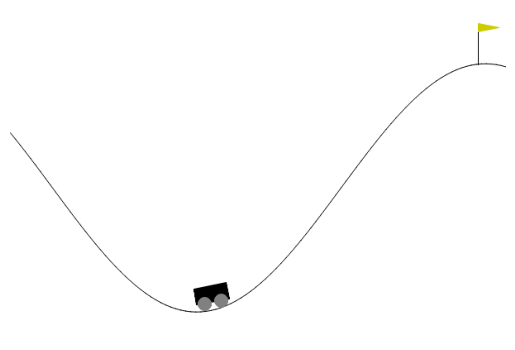

In [6]:
# Se crea el entorno MountainCar
env = gym.make(env_name, render_mode="rgb_array")

# Se resetea el estado usando la semilla
env.reset(seed=SEED)

# Se explora la estructura del espacio de acciones
print("Espacio de acciones:")
print(f"\t- Tipo: {env.action_space}")
print(f"\t- Número de acciones: {env.action_space.n}")
print()

# Se exploran los límites inferiores y superiores
# del espacio de estados (no se puede explorar la
# estructura de forma completa ya que MountainCar
# es un entorno continuo)
print("Espacio de estados:")
print(f"\t- Tipo: {env.observation_space}")
print(f"\t- Límites inferiores: {env.observation_space.low}")
print(f"\t- Límites superiores: {env.observation_space.high}")

# Se renderiza el estado por pantalla
img = env.render()
plt.axis("off")
plt.imshow(img)
plt.show()

Esta salida nos dice lo siguiente:

- El espacio de acciones es `Discrete(3)`, es decir, hay exactamente 3 acciones posibles, codificadas como enteros:
  - 0: empujar hacia la izquierda.
  - 1: no hacer nada.
  - 2: empujar hacia la derecha.
  
- El espacio de estados es continuo y bidimensional:
  - La primera dimensión es la posición del coche, que va desde -1,2 hasta 0,6.
  - La segunda dimensión es la velocidad, que va desde -0,07 hasta 0,07.
  
A continuación, se lleva a cabo un episodio para comprobar cómo funciona el entorno.

In [7]:
# Hacemos un episodio aleatorio para ver cómo funciona
state, info = env.reset(seed=SEED)

print("Estado inicial:")
print(f"\t- Estado: {state}")
print(f"\t- Posición: {state[0]:.4f}")
print(f"\t- Velocidad: {state[1]:.4f}")
print()

# Se ejecutan los 3 primeros pasos tomando acciones
# completamente aleatorias
print("Primeros 3 pasos:")
for i in range(3):
    # Se elige una acción cualquiera del espacio
    # de acciones
    action = env.action_space.sample()

    # Se toma la acción y se recoge información sobre
    # el estado siguiente, la recompensa, si el nuevo
    # estado es terminal, si el episodio se ha truncado
    # por haber alcanzado el límite de pasos (200 por
    # defecto en MountainCar) e información adicional
    next_state, reward, terminated, truncated, info = env.step(action)

    # Se imprime por pantalla información sobre el
    # nuevo estado
    print(f"\t- Paso {i+1}:")
    print(f"\t\t- Acción: {action}")
    print(f"\t\t- Recompensa: {reward}")
    print(f"\t\t- Posición: {next_state[0]:.4f}")
    print(f"\t\t- Velocidad: {next_state[1]:.4f}")
    print(f"\t\t- Terminado: {terminated}")

# Se cierra el entorno ya que hemos dejado de
# usarlo (al menos por ahora)
env.close()

Estado inicial:
	- Estado: [-0.46352962  0.        ]
	- Posición: -0.4635
	- Velocidad: 0.0000

Primeros 3 pasos:
	- Paso 1:
		- Acción: 0
		- Recompensa: -1.0
		- Posición: -0.4650
		- Velocidad: -0.0014
		- Terminado: False
	- Paso 2:
		- Acción: 2
		- Recompensa: -1.0
		- Posición: -0.4659
		- Velocidad: -0.0009
		- Terminado: False
	- Paso 3:
		- Acción: 2
		- Recompensa: -1.0
		- Posición: -0.4662
		- Velocidad: -0.0003
		- Terminado: False


Esta salida nos dice lo siguiente:

- El estado inicial comienza en la posición -0,4635 en el eje X con una velocidad nula (el coche se encuentra en un valle).

- En los tres pasos dados se eligen acciones aleatorias. `Terminado` es `False` en las tres ya que el coche no ha llegado a la meta, y la recompensa es -1 en cada paso ya que el coche es penalizado con una recompensa de -1 por cada paso que tarda sin alcanzar la cima. Esto incentiva al agente a alcanzar la cima lo más rápido posible.

## 3. Transformación de un problema continuo en un problema discreto mediante el uso de Tile Coding.

El siguiente paso consiste en implementar Tile Coding para poder utilizar métodos tabulares en un entorno continuo. Esta técnica permite transformar un estado continuo en un vector de características binario que puede usarse con algoritmos como SARSA semi-gradiente.

La idea más simple consistiría en dividir el espacio de estados en una rejilla. Si en MountainCar se tienen dos dimensiones (posición en el eje x y velocidad) se podría dividir cada dimensión en 8 intervalos, creando una rejilla de $8 \times 8 = 64$ teselas. El problema es que esta rejilla por sí sola no permite generalizar, pues dos estados muy parecidos pueden caer en teselas distintas, por lo que a ojos del Tile Coding son dos estados completamente distintos. La solución consiste en utilizar múltiples rejillas superpuestas y ligeramente desplazadas. Ahora, un estado puede activar numerosas teselas, una por cada rejilla. Dos estados similares activarán muchas teselas parecidas (algunas serán iguales y otras no), y dos estados muy distintos activarán teselas diferentes. Esto permite codificar la similitud entre dos estados cercanos.

Una vez se obtienen los índices de las teselas activadas, se pueden utilizar para construir el vector de características $\mathbf x(s,a)$, haciendo que los índices correspondientes a las teselas activas estén a 1, y los índices correspondientes a teselas inactivas estén a 0. Esto permite codificar el estado, pero no la acción realizada. Para codificar también la acción, se puede tener un bloque de tiles separado para cada acción, y activar solo el bloque correspondiente a la acción realizada, estando los demás a 0.

Para la implementación de la clase `TileCoder` que servirá para la creación del vector de características $\mathbf x(s,a)$ se utilizará la librería `tiles3` de Sutton, permitiendo simplificar los cálculos. Esta librería cuenta con utilidades para calcular automáticamente el índice correspondiente a una tesela utilizando una función hash.

In [8]:
# Esta clase define la codificación que utilizaremos
# para codificar el estado continuo de MountainCar
# de forma discreta usando Tile Coding
class TileCoder:
    def __init__(self, num_tilings:int, num_tiles:int, num_actions:int,
                 pos_min:float, pos_max:float, vel_min:float, vel_max:float):
        """
            El constructor de la clase TileCoder.

        Args:
            num_tilings (int):  El número de rejillas superpuestas que se van
                                a usar.

            num_tiles (int):    El número de teselas por dimensión en cada
                                rejilla.

            num_actions (int):  El número de acciones posibles.

            pos_min (float):    El menor valor de posición que puede tener
                                el agente en MountainCar.

            pos_max (float):    El mayor valor de posición que puede tener
                                el agente en MountainCar.

            vel_min (float):    El menor valor de velocidad que puede tener
                                el agente en MountainCar.

            vel_max (float):    El mayor valor de velocidad que puede tener
                                el agente en MountainCar.
        """

        # Se almacenan los parámetros en atributos del objeto
        self.num_tilings = num_tilings
        self.num_tiles = num_tiles
        self.num_actions = num_actions
        self.pos_min, self.pos_max = pos_min, pos_max
        self.vel_min, self.vel_max = vel_min, vel_max

        # Se calcula el tamaño total que va a tener el vector de
        # características. Cada rejilla tiene num_tiles^2 teselas,
        # y tenemos num_tilings rejillas. Se multiplica por num_actions
        # para separar los parámetros por acción.
        self.size = num_tilings * (num_tiles ** 2) * num_actions

        # IHT significa Index Hash Table, y es una estructura de tiles3
        # que se encarga de mapear teselas a posiciones en el vector
        # de características
        self.iht = IHT(self.size)

    def _scale(self, pos:float, vel:float):
        """
            Esta función auxiliar escala la posición y velocidad
            al rango [0, num_tiles]. Esto es necesario porque tiles3
            trabaja con coordenadas escaladas, y necesita que el rango
            de cada dimensión corresponda al número de tiles.

        Args:
            pos (float):    Posición del coche.

            vel (float):    Velocidad del coche.
        """

        pos_scaled = self.num_tiles * (pos - self.pos_min) / (self.pos_max - self.pos_min)
        vel_scaled = self.num_tiles * (vel - self.vel_min) / (self.vel_max - self.vel_min)
        return pos_scaled, vel_scaled

    def get_features(self, state, action):
        """
            Dado un estado (posición, velocidad) y una acción,
            devuelve el vector de características binario x(s,a).

            En lugar de devolver el vector completo (que puede tener
            muchos ceros) se devuelven solo los índices donde el
            vector vale 1.

        Args:
            state:  Estado que queremos usar para el Tile Coding.
            action: Acción que queremos usar para el Tile Coding.
        """

        # Se extrae la posición y la velocidad
        pos, vel = state[0], state[1]

        # Se escala la posición y la velocidad
        pos_scaled, vel_scaled = self._scale(pos, vel)

        # La función tiles() de tiles3 devuelve una lista
        # de num_tilings índices, uno por rejilla. Cada índice
        # indica qué tile está activo en en esa rejilla para
        # las coordenadas dadas. El argumento [action] permite
        # separar los parámetros por acción
        active_tiles = tiles(self.iht, self.num_tilings,
                             [pos_scaled, vel_scaled],
                             [action])

        return active_tiles

    def compute_q(self, state, action, weights):
        """
            Calcula Q̂(s, a, w) = w^T · x(s, a).
            Como x(s,a) es binario, esto equivale a sumar
            los pesos correspondientes a las teselas activas

        Args:
            state:      Estado que queremos usar para calcular Q̂.

            action:     Estado que queremos usar para calcular Q̂.

            weights:    Vector w de parámetros.

        Returns:
            Valor de Q̂(s, a, w).
        """
        # Se obtiene una lista que indica qué teselas están
        # activas para cada rejilla
        active_tiles = self.get_features(state, action)

        # Ahora, se encuentran los pesos del vector w
        # correspondientes con esas teselas y se suman
        # para calcular Q̂
        return np.sum(weights[active_tiles])

    def compute_all_q(self, state, weights):
        """
            Este método es similar a compute_q(), pero se diferencia
            en que calcula Q̂(s, a, w) para todas las acciones a la
            vez. Esto es útil para la política greedy, donde es
            necesario comparar el valor de Q̂ para todas las acciones
            y así poder elegir la acción con mejor Q̂.

        Args:
            state:      Estado que queremos usar para calcular Q̂.

            weights:    Vector w de parámetros.

        Returns:
            Una lista con el valor de Q̂(s, a, w) para cada una de las
            acciones posibles.
        """
        # Se devuelve una lista con el valor de Q̂ para cada acción
        return [self.compute_q(state, a, weights) for a in range(self.num_actions)]

Una vez tenemos una clase que se encarga del Tile Coding, se verifica que funciona correctamente. Los hiperparámetros elegidos (8 rejillas de tamaño 8x8 cada una) son los recomendados por Sutton y Barto para este problema concreto, pues 8 rejillas es suficiente para una generalización suave, y una rejilla de $8 \times 8$ da una resolución equilibrada del espacio de estados. Con estos valores el vector tiene $8 \times 8^2 \times 3 = 1536$ componentes, lo cual es un número manejable.

In [9]:
# Se eligen los hiperparámetros: 8 rejillas, cada
# una de 8x8 mosaicos, con 3 acciones posibles
num_tilings = 8
num_tiles = 8
num_actions = 3

# Se recoge información sobre los límites inferiores
# y superiores de las dimensiones del entorno
env.reset(seed=SEED)

pos_min, pos_max = env.observation_space.low[0], env.observation_space.high[0]
vel_min, vel_max = env.observation_space.low[1], env.observation_space.high[1]

print("Límites de las dimensiones del entorno:")
print(f"\t- Posición: [{pos_min:.4f},{pos_max:.4f}]")
print(f"\t- Velocidad: [{vel_min:.4f},{vel_max:.4f}]")

# Se instancia del Tile Coder
coder = TileCoder(num_tilings, num_tiles, num_actions, pos_min, pos_max, vel_min, vel_max)

# Se imprime por pantalla el tamaño del vector x(s, a)
print(f"Tamaño del vector de características: {coder.size}")

Límites de las dimensiones del entorno:
	- Posición: [-1.2000,0.6000]
	- Velocidad: [-0.0700,0.0700]
Tamaño del vector de características: 1536


Una vez creado el Tile Coder de ejemplo, se puede hacer una prueba con estados creados artificialmente.

In [10]:
# Se prueba con un estado de ejemplo donde el
# coche esté quieto en el valle
state = np.array([-0.5, 0.0])

# Ahora, se itera por cada acción y se muestran las
# teselas activas
for action in range(num_actions):
    active_tiles = coder.get_features(state, action)
    print(f"Acción {action}: teselas activas en posiciones {active_tiles}")

Acción 0: teselas activas en posiciones [0, 1, 2, 3, 4, 5, 6, 7]
Acción 1: teselas activas en posiciones [8, 9, 10, 11, 12, 13, 14, 15]
Acción 2: teselas activas en posiciones [16, 17, 18, 19, 20, 21, 22, 23]


A contonuación, se comprueba si un estado muy cercano al anterior comparte teselas.

In [11]:
# Este estado se parece bastante al estado del
# bloque de código anterior
state2 = np.array([-0.49, 0.001])
for action in range(num_actions):
    active_tiles_1 = coder.get_features(state, action)
    active_tiles_2 = coder.get_features(state2, action)
    print(f"Acción {action} con el estado 1: {active_tiles_1}")
    print(f"Acción {action} con el estado 2: {active_tiles_2}")
    print()

Acción 0 con el estado 1: [0, 1, 2, 3, 4, 5, 6, 7]
Acción 0 con el estado 2: [0, 1, 2, 3, 4, 5, 6, 24]

Acción 1 con el estado 1: [8, 9, 10, 11, 12, 13, 14, 15]
Acción 1 con el estado 2: [8, 9, 10, 11, 12, 13, 14, 25]

Acción 2 con el estado 1: [16, 17, 18, 19, 20, 21, 22, 23]
Acción 2 con el estado 2: [16, 17, 18, 19, 20, 21, 22, 26]



Como era de esperar, 7 de las 8 teselas son iguales para las tres acciones. Ahora, se comprueba si dos estados muy distintos no comparten teselas.

In [12]:
# Este estado es muy distinto al estado
# state creado anteriormente
state3 = np.array([0.4, 0.05])

for action in range(num_actions):
    active_tiles_1 = coder.get_features(state, action)
    active_tiles_3 = coder.get_features(state3, action)
    print(f"Acción {action} con el estado 1: {active_tiles_1}")
    print(f"Acción {action} con el estado 3: {active_tiles_3}")
    print()

Acción 0 con el estado 1: [0, 1, 2, 3, 4, 5, 6, 7]
Acción 0 con el estado 3: [27, 28, 29, 30, 31, 32, 33, 34]

Acción 1 con el estado 1: [8, 9, 10, 11, 12, 13, 14, 15]
Acción 1 con el estado 3: [35, 36, 37, 38, 39, 40, 41, 42]

Acción 2 con el estado 1: [16, 17, 18, 19, 20, 21, 22, 23]
Acción 2 con el estado 3: [43, 44, 45, 46, 47, 48, 49, 50]



Se puede comprobar que ninguna tesela coincide. Esto confirma que el Tile Coding está capturando correctamente la geometría del espacio de estados.

## 4. Implementación del agente SARSA semi-gradiente.

El agente SARSA semi-gradiente que se implementará contará con un decaimiento lineal de la tasa de aprendizaje $\alpha$ para permitir un aprendizaje más agresivo durante los primeros episodios de entrenamiento. Conforme avanza el entrenamiento, la nueva información no incluye tanto como la información recopilada con anterioridad.

A la hora de elegir una acción, durante el entrenamiento se seguirá una política $\epsilon$-decay, que es un tipo de política $\epsilon$-soft siempre que el valor mínimo de $\epsilon$ sea mayor que 0. Esto garantiza que durante los primeros episodios se explore más intensamente, disminuyendo la exploración en favor de la explotación conforme avanza el entrenamiento. Durante la evaluación se seguirá una política greedy puramente explotadora, pues el agente ya no está aprendiendo, por lo que no merece la pena explorar.

Para aprovechar la orientación a objetos que ofrece Python y la encapsulación y modularidad que supone el uso de clases, se creará una clase `SARSAAgent` para el agente SARSA.

In [13]:
# El agente es construido como una clase que encapsula
# toda la lógica del algoritmo: el vector w de parámetros,
# la política epsilon-greedy y la actualización
# semi-gradiente
class SARSAAgent:
    def __init__(self, tile_coder:TileCoder, alpha_start:float, alpha_min:float, alpha_decay:float, gamma:float, epsilon_start:float, epsilon_min:float, epsilon_decay:float, seed:int):
        """
            El constructor de la clase SARSAAgent, que se encarga
            de preparar el agente para su posterior uso.

        Args:
            tile_coder (TileCoder): Instancia de la clase TileCoder que se usará
                                    para crear el vector de características x(s,a)
                                    cuando sea necesario.

            alpha_start (float):    Tasa de aprendizaje inicial.

            alpha_min (float):      Valor mínimo de la tasa de aprendizaje que se puede
                                    obtener tras el decaimiento.

            alpha_decay(float):     Factor de decaimiento de la tasa de aprendizaje
                                    para decaimiento lineal.

            gamma (float):          Factor de descuento aplicado a recompensas futuras.

            epsilon_start (float):  Probabilidad de exploración inicial.

            epsilon_min (float):    Valor mínimo de la probabilidad de exploración que
                                    se puede obtener tras el decaimiento.

            epsilon_decay(float):   Factor de decaimiento de la probabilidad de exploración
                                    para decaimiento lineal.

            seed (int):             Semilla para la generación pseudoaleatoria de números.
        """

        # Generador pseudoaleatorio de números
        self.rng = np.random.default_rng(seed=seed)

        # Se almacenan los parámetros en atributos del objeto
        self.coder = tile_coder
        self.gamma = gamma
        self.alpha_start = alpha_start
        self.alpha_min = alpha_min
        self.alpha_decay = alpha_decay
        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Se indica que el agente está en modo entrenamiento
        # por defecto (se tiene en cuenta epsilon)
        self.training_mode = True

        # Se extrae el número de acciones posibles
        self.num_actions = tile_coder.num_actions

        # Se inicializan todos los pesos a cero. Con w siendo
        # un vector de ceros, el valor Q inicial para cualquier
        # par (s,a) va a ser 0. En MountainCar todas las
        # recompensas son -1, por lo que el agente empieza siendo
        # un poco optimista (espera 0 pero obtiene -1). Este
        # optimismo incentiva al agente a explorar
        self.weights = np.zeros(tile_coder.size)

        # Dividimos alpha entre num_tilings. Esto se debe a que en
        # cada actualización sumamos alpha x delta a num_tilings pesos
        # (uno por cada tesela activa). Si alpha es 0,5 y tenemos 8 rejillas,
        # estaríamos aplicando un alpha de 4, y no es eso lo que queremos
        # en realidad
        # self.alpha = alpha / tile_coder.num_tilings

    def get_q(self, state, action):
        """
            Dado un estado s y una acción a, devuelve Q̂(s, a, w).

        Args:
            state:  Estado s para el cálculo de Q̂(s, a, w).

            action: Acción a para el cálculo de Q̂(s, a, w).

        Returns:
            Un valor Q̂(s, a, w).
        """
        # Se delega en el Tile Coder desarrollado para que
        # calcule Q̂(s, a, w)
        return self.coder.compute_q(state, action, self.weights)

    def get_epsilon(self, episode:int):
        """
            Según el episodio actual, devuelve el valor de epsilon,
            el cual tiene un decaimiento lineal

        Args:
            episode (int): Episodio de entrenamiento.

        Returns:
            Valor de epsilon correspondiente al episodio actual.
        """
        return max(self.epsilon_min, self.epsilon_start * (self.epsilon_decay**episode))

    def choose_action(self, state, episode:int=None):
        """
            Dado el estado y el episodio actual, elige una acción
            siguiendo la política epsilon-greedy.

        Args:
            state:      Estado para el que se quiere elegir la acción.

            episode:    Episodio en el que se encuentra el agente. Solo
                        es necesario durante el entrenamiento para el
                        cálculo del epsilon tras el decaimiento lineal.

        Returns:
            Estado elegido.
        """

        # Epsilon inicia siendo 0 (política greedy)
        epsilon=0

        # En caso de estar en modo entrenamiento, se
        # actualiza epsilon para tener en cuenta el
        # epsilon inicial y el decaimiento de este
        if self.training_mode:
            epsilon = self.get_epsilon(episode)

        if self.training_mode and self.rng.random() < epsilon:
            # Con probabilidad epsilon se explora (se elige
            # una acción aleatoria) solo si se está entrenando
            return self.rng.integers(low=0,high=self.num_actions)
        else:
            # Con probabilidad 1-epsilon se explota (se
            # elige la mejor acción, es decir, la acción
            # con mejor valor Q). Si no se está entrenando,
            # siempre se explota
            q_values = self.coder.compute_all_q(state, self.weights)
            return np.argmax(q_values)

    def set_training_mode(self, training_mode:bool):
        """
            Activa o desactiva el modo de entrenamiento. Cuando el modo
            de entrenamiento está activo, se tiene en cuenta epsilon a
            la hora de elegir la mejor acción. Si no está activo, no
            se tiene en cuenta epsilon (se sigue una política greedy
            puramente explotadora)

        Args:
            training_mode (bool):   Indica si se quiere establecer o no
                                    el modo de entrenamiento.
        """
        self.training_mode = training_mode

    def get_alpha(self, episode:int):
        """
            Según el episodio actual, devuelve el valor de alpha,
            el cual tiene un decaimiento lineal

        Args:
            episode (int): Episodio de entrenamiento.

        Returns:
            Valor de alpha correspondiente al episodio actual.
        """
        return max(self.alpha_min, self.alpha_start * (self.alpha_decay**episode))

    def update(self, state, action, reward:float, terminated:bool, episode:int, next_state=None, next_action=None):
        """
            Realiza la actualización semi-gradiente de SARSA:
            w <- w + alpha · delta · x(s,a)

        Args:
            state:              El estado actual s.

            action:             La acción actual a.

            reward (float):     La recompensa obtenida r.

            terminated (bool):  True si el episodio ha terminado.

            episode (int):      Episodio de entrenamiento.

            next_state:         El siguiente estado s'. None por defecto.

            next_action:        La siguiente acción a'. None por defecto.
        """

        if terminated:
            assert next_state is None and next_action is None, "Se ha indicado que el episodio ha terminado pero se ha proporcionado un siguiente estado s' y/o una siguiente acción a'."
        else:
            assert next_state is not None and next_action is not None, "Se ha indicado que el episodio aún no ha terminado pero no se ha proporcionado un siguiente estado s' y/o una siguiente acción a'."

        # Se calcula la estimación actual Q̂(s, a, w)
        q_current = self.get_q(state, action)

        # Se calcula el target. Si el episodio ha terminado, no hay
        # estado siguiente y el target es simplemente la recompensa
        # inmediata sin bootstrapping. Si no ha terminado, se usa
        # la ecuación de Bellman.
        if terminated:
            target = reward
        else:
            q_next = self.get_q(next_state, next_action)
            target = reward + self.gamma * q_next

        # Se calcula el error TD
        delta = target - q_current

        # Se obtiene el valor de alpha correspondiente al
        # episodio actual según el decaimiento lineal
        alpha = self.get_alpha(episode)

        # Se divide el alpha entre el número de tilings que
        # se tienen en el Tile Coder
        alpha /= self.coder.num_tilings

        # Se actualizan los pesos. Como x(s,a) es binario, solo se
        # actualizan los pesos de las teselas activas, sumando a
        # cada una alpha · delta
        active_tiles = self.coder.get_features(state, action)
        self.weights[active_tiles] += alpha * delta

Ahora que se tiene la clase `SARSAAgent`, antes de escribir el bucle de entrenamiento conviene hacer una comprobación rápida de que el agente actualiza los pesos correctamente.

In [14]:
# Se crea el agente con hiperparámetros cualesquiera
coder = TileCoder(num_tilings, num_tiles, num_actions, pos_min, pos_max, vel_min, vel_max)
agent = SARSAAgent(tile_coder=coder, alpha_start = 0.5, alpha_min = 0.01, alpha_decay = 0.995, gamma = 1.0, epsilon_start = 0.3, epsilon_min = 0.01, epsilon_decay = 0.995, seed=SEED)

# Se crea un estado inicial de ejemplo
state = np.array([0.5, 0.0])
action = agent.choose_action(state,episode=0)

# Se imprime información por pantalla
print(f"Acción elegida: {action}")
print(f"Q inicial para esta acción: {agent.get_q(state, action):.4f}")
print(f"Suma total de pesos antes: {np.sum(agent.weights):.4f}")

Acción elegida: 0
Q inicial para esta acción: 0.0000
Suma total de pesos antes: 0.0000


Como es de esperar, todo empieza siendo 0 ya que se ha decidido inicializar todo a 0. Si ahora se simula un paso, se puede ver cómo se actualiza el agente:

In [15]:
# Se simula un paso en el que se recibe una recompensa
# de -1
next_state = np.array([-0.51, -0.001])
next_action = agent.choose_action(next_state,episode=0)
agent.update(state, action, reward=-1, terminated=False,episode=0, next_state=next_state, next_action=next_action)

# Ahora, se imprime por pantalla la información después
# de la actualización
print("Después de la actualización:")
print(f"Q para la misma acción: {agent.get_q(state, action):.4f}")
print(f"Suma total de pesos después: {np.sum(agent.weights):.4f}")

Después de la actualización:
Q para la misma acción: -0.5000
Suma total de pesos después: -0.5000


Como era de esperar, el agente ha actualizado sus pesos y ha disminuido Q para el mismo par (s,a), pues el agente ha recibido una recompensa de -1.

## 5. Entrenamiento del agente SARSA semi-gradiente y búsqueda de hiperparámetros.

Ahora que el agente entero está implementado, se puede desarrollar el bucle completo de entrenamiento. Para esto, se define la función `train`, donde se ejecutan episodios repetidamente para actualizar el vector $\mathbf w$ de parámetros.

In [16]:
def train(env:gym.Env, agent:SARSAAgent, num_episodes:int, train_seed:int, show_progress:bool=True):
    """
        Se ejecuta el bucle de entrenamiento completo de SARSA
        semi-gradiente. La función se encarga de resetear el
        entorno, pero NO de cerrarlo.

    Args:
        env (gym.Env):          El entorno MountainCar en el que se
                                desenvuelve el agente.

        agent (SARSAAgent):     El agente que se está entrenando.

        num_episodes (int):     El número de episodios que queremos hacer.

        train_seed (int):       Semilla a utilizar.

        show_progress(bool):    Indica si se debe mostrar una barra de progreso.
                                Por defecto es True.

    Returns:
        Una lista con la recompensa total de cada episodio.
    """

    # Se activa el modo de entrenamiento del agente
    agent.set_training_mode(True)

    # Esta es la lista que se va a devolver, que contiene
    # las recompensas obtenidas en cada epsodio
    rewards_per_episode = []

    # Según si se quiere mostrar o no el progreso, se
    # usará un iterador u otro
    if show_progress:
        episodes = tqdm(range(num_episodes))
    else:
        episodes = range(num_episodes)

    for episode in episodes:
        # Se inicia el episodio y se obtiene el estado inicial
        state, _ = env.reset(seed=train_seed)

        # Se elige la primera acción en base al estado inicial
        action = agent.choose_action(state, episode)

        # La recompensa comienza siendo 0, pero se irá
        # actualizando conforme avanza el episodio
        total_reward = 0

        # Al terminar el episodio, uno de estos flags será True,
        # indicando si el episodio ha terminado porque el agente
        # ha alcanzado la meta (terminated a True) o porque se ha
        # alcanzado el número máximo de pasos dentro de un episodio
        terminated = False
        truncated = False

        # Se itera paso a paso dentro de este episodio
        while not (terminated or truncated):

            # Se ejecuta la acción en el entorno
            next_state, reward, terminated, truncated, _ = env.step(action)

            # La recompensa total se actualiza
            total_reward += reward

            # Se elige la siguiente acción antes de actualizar (esa
            # es la gracia de SARSA: se utiliza el estado siguiente
            # y la acción siguiente)
            if not (terminated or truncated):
                next_action = agent.choose_action(next_state, episode)

            if terminated:
                # Si el episodio ha terminado, se actualizan los pesos
                # usando la tupla (s,a,r)
                agent.update(state, action, reward, terminated, episode)
            else:
                # Si aún no ha terminado (o si ha terminado por
                # truncamiento) se actualizan los pesos con la tupla
                # (s,a,r,s',a')
                agent.update(state, action, reward, terminated, episode,
                             next_state=next_state,next_action=next_action)

            # Se avanza al siguiente paso (solo si no se ha terminado
            # el episodio)
            if not (terminated or truncated):
                state = next_state
                action = next_action

        # Tras terminar un episodio, se añade la recompensa total a
        # la lista de recompensas
        rewards_per_episode.append(total_reward)

        # Se incrementa la semilla en 1 para obtener un nuevo entorno
        # de entrenamiento
        train_seed+=1

    # Se devuelve la lista de recompensas
    return rewards_per_episode

Como se va a realizar una búsqueda de hiperparámetros para encontrar la combinación que ofrece mejores resultados, se implementa también la función de evaluación, similar a la función de entrenamiento pero sin actualización de pesos. Esta función permitirá evaluar el rendimiento de un agente entrenado a lo largo de varios episodios ejecutados en entornos distintos, pudiendo verificar si el aprendizaje ha sido efectivo.

In [17]:
def evaluate(env:gym.Env, agent:SARSAAgent, num_episodes:int, eval_seed:int, show_progress:bool=True):
    """
        Esta función evalúa un agente SARSA entrenado en un
        entorno. La evaluación se realiza sin exploración
        (epsilon=0). La función se encarga de resetear el
        entorno, pero NO de cerrarlo.

    Args:
        env (gym.Env):          Entorno que se usará para la evaluación del agente.

        agent (SARSAAgent):     Agente a evaluar.

        num_episodes (int):     Número de episodios durante los que se evaluará el agente.

        eval_seed (int):        Semilla a utilizar.

        show_progress(bool):    Indica si se debe mostrar una barra de progreso.
                                Por defecto es True.

    Returns:
        Una lista con las recompensas obtenidas en cada episodio.
    """

    # Se desactiva el modo de entrenamiento del agente
    agent.set_training_mode(False)

    # Esta será la lista que se devolverá
    eval_rewards = []

    # Esta lista almacena todos los estados por los que pasa
    # el agente durante la evaluación
    all_states = []

    # Según si se quiere mostrar o no el progreso, se
    # usará un iterador u otro
    if show_progress:
        episodes = tqdm(range(num_episodes))
    else:
        episodes = range(num_episodes)

    # Se itera por cada episodio
    for episode in episodes:
        # En esta lista se almacenan los estados por los que
        # va pasando el agente en cada paso temporal
        states_this_episode = []

        # Se resetea el episodio usando la semilla
        state, _ = env.reset(seed=eval_seed)
        states_this_episode.append(state)

        # La recompensa inicial es 0
        total_reward = 0

        # Al terminar el episodio, solo uno de
        # estos flags debe ser True
        terminated = False
        truncated = False

        # Se itera por cada paso temporal de este episodio
        while not (terminated or truncated):
            action = agent.choose_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            states_this_episode.append(state)
            total_reward += reward

        # Se añade la recompensa total obtenida a la lista de
        # recompensas
        eval_rewards.append(total_reward)

        # La semilla irá cambiando en cada episodio para
        # que cada evaluación sea distinta. En este caso, la
        # semilla se decrementa en 1 en cada episodio, garantizando
        # que los entornos de evaluación y de entrenamiento sean
        # distintos
        eval_seed -= 1

        # Se añade la lista de estados de este episodio a la lista
        # de listas de estados
        all_states.append(states_this_episode)

    # Se devuelve la lista de recompensas y de todos los estados
    return eval_rewards, all_states

Teniendo ya preparadas ambas funciones, se definen los hiperparámetros que se evaluarán durante el grid search, y se realiza la búsqueda de hiperparámetros, para la cual se entrena un agente por cada combinación de hiperparámetros y se evalúa en varios episodios con entornos distintos. Al final, la combinación correspondiente al agente con mejor recompensa media durante la evaluación se elige como combinación ganadora.

In [18]:
# Número de rejillas para el Tile Coding (se fija
# en 8)
num_tilings = 8

# Dimensión de cada rejilla (se tienen rejillas
# cuadradas, así que un valor de 8 indica una
# rejilla de tamaño 8x8)
num_tiles = 8

# La tasa de aprendizaje inicial (se dividirá entre num_tilings)
alpha_start_grid = [0.3,0.5]

# El valor mínimo de la tasa de aprendizaje no cambia
alpha_min = 0.01

# El factor de decaimiento de la tasa de aprendizaje
alpha_decay_grid = [0.995,0.99,0.95]

# La tasa de descuento
gamma_grid = [0.9,0.95]

# Probabilidad de exploración inicial
epsilon_start_grid = [0.1,0.3]

# El valor mínimo de la probabilidad de exploración
# no cambia
epsilon_min = 0.01

# El factor de decaimiento de la probabilidad de
# exploración
epsilon_decay_grid = [0.995, 0.99, 0.95]

# Siempre se tienen 3 acciones
num_actions = 3

# Durante el grid search se entrenará cada agente durante 200 episodios
num_training_episodes = 200

# Durante el grid search se evaluará cada agente durante 10 episodios
num_evaluation_episodes = 20

# En este diccionario se almacenará la recompensa media de cada combinación
# durante la evaluación
reward_dict = dict()

# Se crea el entorno, el Tile Coder y el agente SARSA
env = gym.make(env_name)

# Se itera por cada combinación de hiperparámetros
for alpha_start,alpha_decay,gamma,epsilon_start,epsilon_decay in tqdm(product(alpha_start_grid, alpha_decay_grid, gamma_grid, epsilon_start_grid, epsilon_decay_grid),
                                                                              total=len(alpha_start_grid)*len(alpha_decay_grid)*len(gamma_grid)*len(epsilon_start_grid)*len(epsilon_decay_grid)):
    pos_min, pos_max = env.observation_space.low[0], env.observation_space.high[0]
    vel_min, vel_max = env.observation_space.low[1], env.observation_space.high[1]
    coder = TileCoder(num_tilings, num_tiles, num_actions, pos_min, pos_max, vel_min, vel_max)
    agent = SARSAAgent(coder, alpha_start, alpha_min, alpha_decay, gamma, epsilon_start, epsilon_min, epsilon_decay, seed=SEED)

    # Comienza el entrenamiento
    train_rewards = train(env, agent, num_training_episodes, SEED, show_progress=False)

    # Se evalúa el agente
    eval_rewards, _ = evaluate(env, agent, num_evaluation_episodes, SEED, show_progress=False)

    # Se añade la recompensa media al diccionario
    # de recompensas
    reward_dict[(alpha_start,alpha_decay,gamma,epsilon_start,epsilon_decay)] = np.mean(eval_rewards)

# Se cierra el entorno una vez dejamos de usarlo
env.close()

# Se encuentra la mejor recompensa promedio
best_alpha_start,best_alpha_decay,best_gamma,best_epsilon_start,best_epsilon_decay = max(reward_dict,key=reward_dict.get)

print("Mejor combinación de hiperparámetros:")
print(f"- Tasa de aprendizaje inicial (alpha_start): {best_alpha_start}")
print(f"- Factor de decaimiento de alpha (alpha_decay): {best_alpha_decay}")
print(f"- Factor de descuento (gamma): {best_gamma}")
print(f"- Tasa de exploración inicial (epsilon_start): {best_epsilon_start}")
print(f"- Factor de decaimiento de epsilon (epsilon_decay): {best_epsilon_decay}")

print(f"Recompensa media del agente entrenado usando la mejor combinación de hiperparámetros durante la evaluación: {reward_dict[(best_alpha_start,best_alpha_decay,best_gamma,best_epsilon_start,best_epsilon_decay)]}")

100%|██████████| 72/72 [07:10<00:00,  5.97s/it]

Mejor combinación de hiperparámetros:
- Tasa de aprendizaje inicial (alpha_start): 0.5
- Factor de decaimiento de alpha (alpha_decay): 0.99
- Factor de descuento (gamma): 0.9
- Tasa de exploración inicial (epsilon_start): 0.1
- Factor de decaimiento de epsilon (epsilon_decay): 0.99
Recompensa media del agente entrenado usando la mejor combinación de hiperparámetros durante la evaluación: -116.1


## 6. Análisis del agente entrenado utilizando la mejor combinación de hiperparámetros.

Ahora que se ha encontrado la mejor combinación de hiperparámetros, se entrenará un agente utilizando esta combinación durante más épocas. Para poder visualizar cómo cambia la recompensa obtenida en cada episodio conforme avanza el entrenamiento, se implementa la función `plot_training`.

In [19]:
def plot_training(rewards:list, window=50):
    """
        Esta función dibuja la recompensa por episodio
        y una media móvil para suavizar el ruido y ver
        la tendencia de aprendizaje.

    Args:
        rewards (list[list]):   Una lista donde cada elemento es a su vez una lista
                                con las recompensas obtenidas en cada episodio
                                de la función train.

        labels (list[str]):     Una lista donde cada entrada es un string que sirve
                                como etiqueta para identificar la variante del algoritmo
                                usada para conseguir las recompensas que están en su
                                misma posición pero en la lista rewards.

        window (int, optional): El tamaño de la ventana utilizada para
                                calcular la media móvil.
    """

    # Se obtiene el número de episodios
    episodes = np.arange(len(rewards))

    # Se calculan varias medias móviles usando una
    # ventana de tamaño window para cada algoritmo
    moving_average = [
        np.mean(rewards[max(0, i-window):i+1])
        for i in range(len(rewards))
    ]

    plt.figure(figsize=(10, 5))

    p = plt.plot(episodes, rewards, alpha=0.3, linewidth=0.8, label=f"Recompensa")
    plt.plot(episodes, moving_average, linewidth=2, color=p[0].get_color(), label=f"Media móvil")

    plt.xlabel("Episodio")
    plt.ylabel("Recompensa total")
    plt.title("Aprendizaje de SARSA semi-gradiente en MountainCar-v0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Ahora, se entrena el agente utilizando los mejores hiperparámetros, y se utilizan más épocas tanto para el entrenamiento como para la evaluación.

100%|██████████| 200/200 [00:06<00:00, 32.01it/s]


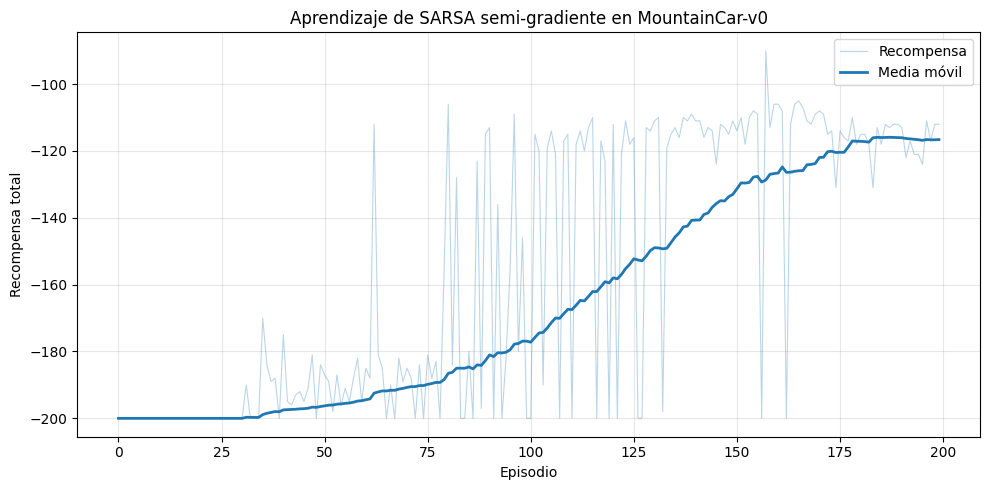

100%|██████████| 100/100 [00:01<00:00, 74.97it/s]

Estadísticas obtenidas durante la evaluación:
Media: -115.5
Desviación típica: 7.6
Mejor recompensa: -109.0
Peor recompensa: -156.0


In [20]:
# Ahora que ha terminado el grid search se entrenará el agente
# durante 200 episodios también
num_definitive_training_episodes = 200

# Número de veces que se repite la evaluación para el agente
num_eval_repetitions = 100

# Se crea el entorno que se usará para la mejor combinación
# de hiperparámetros encontrada
env_best = gym.make(env_name)

pos_min, pos_max = env_best.observation_space.low[0], env_best.observation_space.high[0]
vel_min, vel_max = env_best.observation_space.low[1], env_best.observation_space.high[1]
best_coder = TileCoder(num_tilings, num_tiles, num_actions, pos_min, pos_max, vel_min, vel_max)
best_agent = SARSAAgent(best_coder, best_alpha_start, alpha_min, best_alpha_decay, best_gamma, best_epsilon_start, epsilon_min, best_epsilon_decay, SEED)

# Comienza el entrenamiento
training_rewards = train(env_best, best_agent, num_definitive_training_episodes, SEED)

# Se grafica cómo ha ido el entrenamiento
plot_training(training_rewards)

# Se evalúa el agente
eval_rewards, _ = evaluate(env_best, best_agent, num_eval_repetitions, SEED)

print("Estadísticas obtenidas durante la evaluación:")
print(f"Media: {np.mean(eval_rewards):.1f}")
print(f"Desviación típica: {np.std(eval_rewards):.1f}")
print(f"Mejor recompensa: {np.max(eval_rewards):.1f}")
print(f"Peor recompensa: {np.min(eval_rewards):.1f}")

# Se cierra el entorno
env_best.close()

Tras el entrenamiento, la recompensa promedio obtenida teniendo en cuenta una ventanas de 50 episodios se encuentra sobre -120 (como se muestra en la línea "Media móvil" de la gráfica superior). Esto es un buen indicador, pues MountainCar tiene un número máximo de pasos temporales de 200, por lo que cualquier recompensa mayor que -200 indica que el agente ha sido capaz de llegar a la meta satisfactoriamente.

En cuanto a la evaluación, la recompensa media obtenida es de -115.5, mejor que en el entrenamiento, pues al evaluar se elige siempre la mejor acción ($\epsilon=0$). Con una desviación típica de 7,6 y un rango entre -109 y -156 para las recompensas durante la evaluación, se observa cómo el agente siempre es capaz de encontrar una solución, por lo que se puede concluir que el entrenamiento ha sido todo un éxito.

Una vez vistos los resultados de forma numérica, merece la pena echar un vistazo al funcionamiento del agente de forma gráfica para poder comprobar cómo ha logrado resolver el problema del entorno MountainCar. Se usará la clase `RecordVideo` de Gymnasium para poder mostrar por pantalla los fotogramas generados, donde cada fotograma representa un paso temporal.

In [21]:
def record_agent(agent:SARSAAgent, name_prefix:str, filepath:str="./video"):
    """
        Esta función graba un vídeo donde se muestra
        cómo el agente intenta resolver el problema
        de MountainCar

    Args:
        agent (SARSAAgent):         Agente SARSA que se va a evaluar.

        name_prefix(str):           Prefijo que se le va a colocar al nombre
                                    del vídeo. El nombre será prefijo-episode-0.mp4
                                    (donde "prefijo" es cambiado por el valor de la
                                    variable name_prefix)

        filepath (str, optional):   Ruta del directorio donde se guardará
                                    el vídeo grabado. Por defecto es "./video".
    """

    # Se crea el entorno y se especifica que se quiere renderizar como
    # un array de píxeles en formato RGB
    env_video = gym.make(env_name, render_mode="rgb_array")
    env_video.reset(seed=SEED)

    # Se mete el entorno dentro del wrapper RecordVideo de Gymnasium
    # para que la librería se encargue automáticamente de grabar el
    # vídeo donde se muestre al agente resolviendo MountainCar
    env_video = RecordVideo(env_video, video_folder=filepath,
                            name_prefix=name_prefix,
                            episode_trigger=lambda e: True,
                            disable_logger=True)



    # Se llama a la función evaluate con el entorno y el agente,
    # especificando solo un episodio
    reward_eval, all_states_eval = evaluate(env_video,agent,num_episodes=1,eval_seed=SEED)

    # Se cierra el agente
    env_video.close()

    print(f"Vídeo guardado en {filepath}")
    print(f"Recompensa del episodio grabado: {reward_eval[0]}")

    return reward_eval, all_states_eval

In [22]:
reward_eval, all_states_eval = record_agent(best_agent,"sarsa-semi-gradiente-mejor-agente")

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/FernandezMartinezPolo-EML-RL/Entornos_Complejos/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
100%|██████████| 1/1 [00:00<00:00,  2.06it/s]
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Vídeo guardado en ./video
Recompensa del episodio grabado: -113.0


La recompensa ha sido bastante buena: -113. Si ahora se visualiza el vídeo, se puede comprobar cuál ha sido la estrategia que ha permitido al agente llevar el coche desde el valle hasta la cima.

In [23]:
display(Video("./video/sarsa-semi-gradiente-mejor-agente-episode-0.mp4", embed=True, width=500))

Primero, el coche se mueve un poco hacia la derecha para conseguir impulso hacia la izquierda. Luego, acelera hacia la izquierda para subir la colina y conseguir impuslo hacia la meta. Finalmente, hacelera hacia la derecha para poder llegar correctamente a la meta. Esto demuestra que el agente ha aprendido correctamente a desarrollar una estrategia inteligente para resolver el problema de forma efectiva y eficiente.

Una vez se ha comprobado cómo se mueve el agente por el entorno y cuáles son las recompensas que consigue, es útil visualizar la función Q que ha aprendido. Concretamente, se puede dibujar $V(s) = \max_a\hat{Q}(s,a,w)$ para distintos puntos del espacio de estados, lo que nos da un mapa de zonas que el agente considera favorables.

In [24]:
def plot_value_function(agent:SARSAAgent, pos_min:float, pos_max:float, vel_min:float, vel_max:float):
    """
        Esta función dibuja V(s) = max_a Q̂(s,a,w) para varios
        puntos del espacio de estados (como este espacio es infinito,
        no es posible dibujar todos los V(s), pero es posible obtener
        una aproximación bastante buena). Las zonas más claras son las
        de mayor valor, y las más oscuras son de menor valor.

    Args:
        agent (SARSAAgent): El agente SARSA del que se quiere dibujar
                            la función de valor V(s).

        pos_min (float):    El menor valor de posición que puede tener
                            el agente en MountainCar.

        pos_max (float):    El mayor valor de posición que puede tener
                            el agente en MountainCar.

        vel_min (float):    El menor valor de velocidad que puede tener
                            el agente en MountainCar.

        vel_max (float):    El mayor valor de velocidad que puede tener
                            el agente en MountainCar.
    """

    # Se obtienen varias posiciones y varias velocidades
    positions = np.linspace(pos_min, pos_max, 100)
    velocities = np.linspace(vel_min, vel_max, 100)

    # Se inicializa V como una matriz de ceros
    V = np.zeros((len(velocities), len(positions)))

    # Se rellena la matriz con valores
    for i, vel in enumerate(velocities):
        for j, pos in enumerate(positions):
            # Se crea un estado artificial con la posición y la
            # velocidad de esta entrada de la matriz V
            state = np.array([pos, vel])

            # Se obtienen los Q-valores asociados a este estado y
            # a cada acción posible
            q_values = agent.coder.compute_all_q(state, agent.weights)

            # Se actualiza la matriz V con el mayor Q-valor
            V[i,j] = np.max(q_values)

    # Ahora, se muestra la matriz V por pantalla
    plt.figure(figsize=(8, 6))
    plt.contourf(positions, velocities, V, levels=40, cmap="viridis")
    plt.colorbar(label="$V(s) = \max_a\ \hat{Q}(s, a, w)$")
    plt.xlabel("Posición")
    plt.ylabel("Velocidad")
    plt.title("Función de valor aprendida")

    # Se marca también la posición de la cima
    plt.axvline(x=0.5, color="red", linestyle="--",
                linewidth=1.5, label="Cima (objetivo)")
    plt.legend()
    plt.tight_layout()
    plt.show()

<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2258/1030464594.py:50: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(label="$V(s) = \max_a\ \hat{Q}(s, a, w)$")


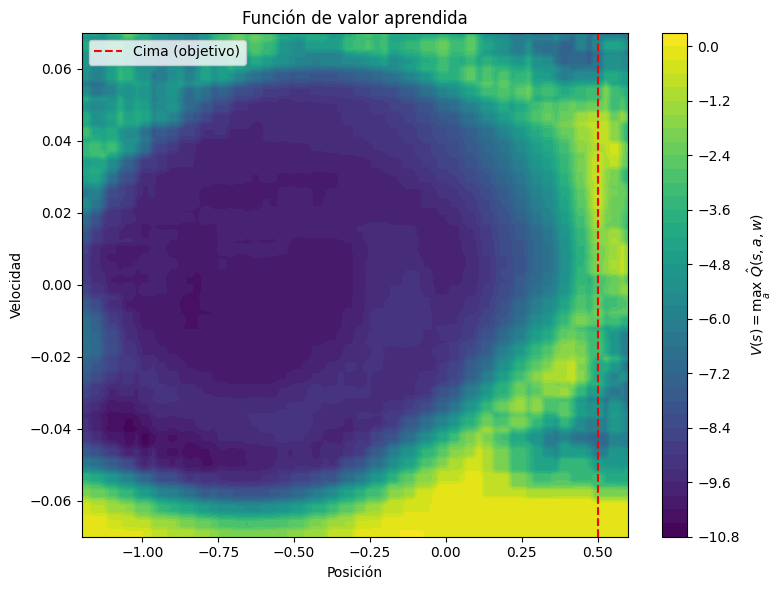

In [25]:
plot_value_function(best_agent, pos_min, pos_max, vel_min, vel_max)

En esta gráfica se grafica la posición en el eje X y la velocidad en el eje Y. Se muestra mucha información sobre lo que el agente ha aprendido:

- Los estados cercanos a la cima (posición cercana a 0,6) tienen un color más claro porque el agente sabe que está cerca de terminar y, por lo tanto, sabe que no va a seguir recibiendo recompensas negativas.

- Los estados situados en el valle tienen un color oscuro cuando el agente está parado, pues eso significa que el agente no está haciendo nada para avanzar. Si el valor absoluto de la velocidad es muy bajo, el agente ve una oportunidad para conseguir impulso y los colores son más claros, y si la velocidad es muy positiva los colores también son claros, representando que el agente está avanzando directamente hacia la meta.

Tras la visualización de la función $V(s)$ en distintos puntos del espacio de estados, es posible visualizar la política aprendida (es decir, dibujar qué acción elegiría el agente en cada punto del espacio de estados).

In [26]:
def plot_policy(agent:SARSAAgent, pos_min:float, pos_max:float, vel_min:float, vel_max:float, all_states:list=None):
    """
        Esta función dibuja la política greedy aprendida. El resultado
        es una gráfica donde, para cada punto elegido del espacio de
        estados, se muestra qué acción habría elegido el agente usando
        colores.

    Args:
        agent (SARSAAgent): Agente SARSA cuya política se quiere visualizar.

        pos_min (float):    El menor valor de posición que puede tener
                            el agente en MountainCar.

        pos_max (float):    El mayor valor de posición que puede tener
                            el agente en MountainCar.

        vel_min (float):    El menor valor de velocidad que puede tener
                            el agente en MountainCar.

        vel_max (float):    El mayor valor de velocidad que puede tener
                            el agente en MountainCar.

        all_states (list):  Lista con todos los estados seguidos durante
                            un episodio de evaluación (opcional).
    """

    # Se obtienen posiciones y velocidades
    positions = np.linspace(pos_min, pos_max, 100)
    velocities = np.linspace(vel_min, vel_max, 100)

    # Se crea una matriz donde para cada posición se
    # almacenará la acción que elegiría el agente
    policy = np.zeros((len(velocities), len(positions)))

    # Se itera por cada estado elegido
    for i, vel in enumerate(velocities):
        for j, pos in enumerate(positions):
            # Se crea un estado artificial con la velocidad
            # y la posición elegidas
            state = np.array([pos, vel])

            # Se extraen los Q-valores para este estado
            q_values = agent.coder.compute_all_q(state, agent.weights)

            # Se obtiene la acción que mejor Q-valor ha
            # reportado
            policy[i, j] = np.argmax(q_values)

    # Se usará un mapa de colores usando 3 colores
    cmap = plt.cm.get_cmap("RdYlGn", 3)

    # Se imprime el mapa de color por pantalla
    fig, ax = plt.subplots(figsize=(8, 6))
    im     = ax.contourf(positions, velocities, policy,
                         levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap)

    # Si se ha proporcionado una lista de estados, se grafican
    if all_states is not None:
        for state in all_states:
            ax.plot(state[0],state[1],"co-")

    cbar = plt.colorbar(im, ticks=[0, 1, 2])
    cbar.set_ticklabels(["Izquierda", "Nada", "Derecha"])
    ax.set_xlabel("Posición")
    ax.set_ylabel("Velocidad")
    ax.set_title("Política greedy aprendida")
    ax.axvline(x=0.5, color="black", linestyle="--",
               linewidth=1.5, label="Cima (objetivo)")
    ax.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2258/2162329809.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn", 3)


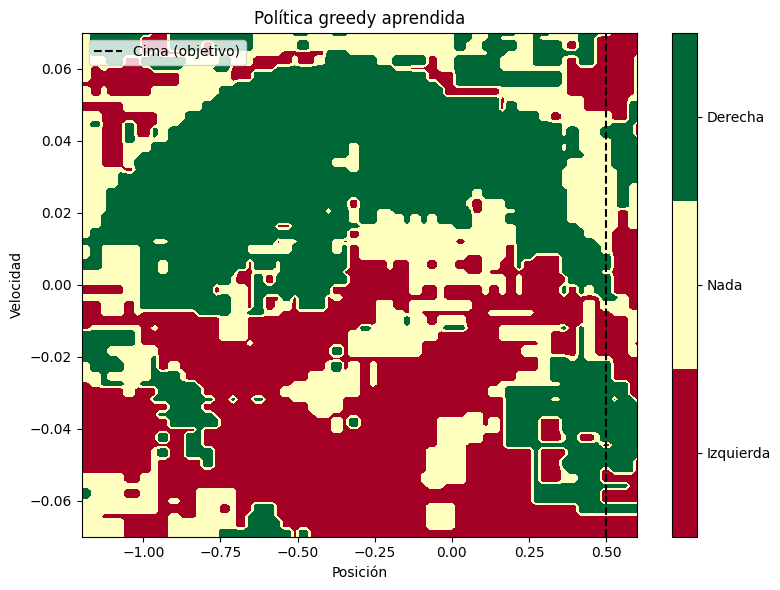

In [27]:
plot_policy(best_agent, pos_min, pos_max, vel_min, vel_max)

Esta gráfica refleja la estrategia que sigue el agente a la hora de resolver MountainCar:

- La parte baja es roja, indicando que el agente prefiere ir a la izquierda si su velocidad es negativa para conseguir impulso.

- La parte alta es verda, indicando que el agente prefiere ir a la derecha si tiene suficiente impulso para poder llegar a la meta velozmente.

Al inicio, el agente puede que se tenga que mover un poco a la derecha para poder ir luego a la izquierda con más impulso y así conseguir llegar a la meta.

Para ver esto de forma más gráfica y clara, se grafica encima del gráfico de la política una serie de puntos que muestran el recorrido del coche por el espacio de estados

/tmp/ipykernel_2258/2162329809.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn", 3)


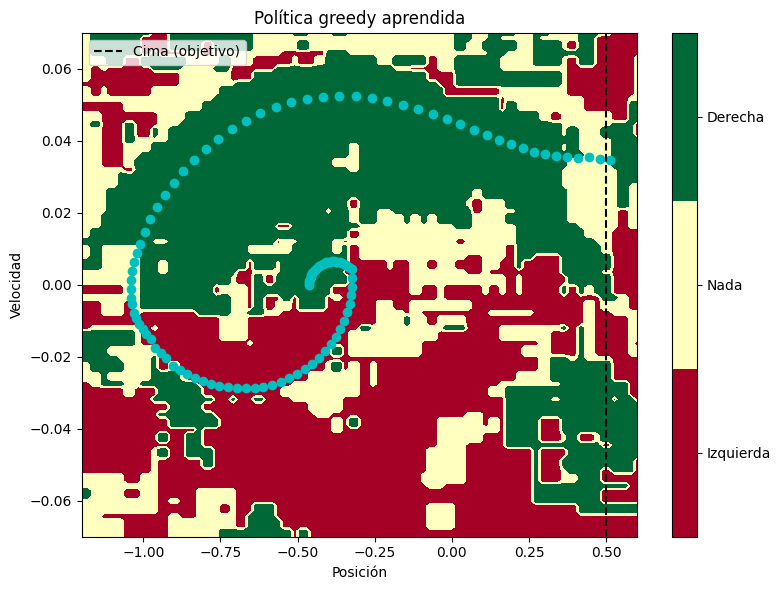

In [28]:
plot_policy(best_agent, pos_min, pos_max, vel_min, vel_max, all_states=all_states_eval[0])

El resultado es justo el esperado: el agente empieza yendo un poco a la derecha para así conseguir impulso hacia la izquierda. Luego, avanza rápidamente hacia la izquierda para así subir alto y poder luego acelerar a fondo hacia la derecha y conseguir un gran impulso hacia la meta.

## 7. Conclusiones.

A lo largo de este notebook se ha demostrado cómo es posible codificar los estados de un entorno continuo para su discretización mediante Tile Coding. Tras esto, es posible resolver el problema utilizando una técnica parametrizada como SARSA semi-gradiente, ganando en generalidad y obteniendo unos buenos resultados. Con los parámetros utilizados inicialmente se ha conseguido crear un agente capaz de resolver MountainCar de forma rápida y eficaz, a pesar de ser un problema con un entorno continuo.

Con 8 rejillas de tamaño 8x8 para el Tile Coding, una tasa de aprendizaje de $\alpha=0.5$, una tasa de descuento de $\gamma=1.0$ y una probabilidad de exploración de $\epsilon=0.1$ se ha entrenado el agente durante 500 episodios, consiguiendo que la recompensa media suba desde -200 (la peor recompensa posible) hasta alrededor de -140 durante el entrenamiento. Durante la evaluación, al seguir una política completamente greedy, la recompensa promedio sube hasta -115, demostrando cómo el agente no solo ha aprendido a resolver el problema, sino que es capaz de hacerlo rápidamente.